# 🛍️ Fashion Multimodal Chatbot Assistant
## Full Pipeline: Preprocessing → Feature Extraction → Image Captioning → Retrieval

**Dataset**: Jumia Egypt Fashion Products  
**Framework**: TensorFlow / Keras ONLY  
**Models**:
1. ResNet50V2 + LSTM + Bahdanau Attention
2. ResNet50 + GRU + Bahdanau Attention
3. EfficientNetB0 + LSTM + Bahdanau Attention
4. **EfficientNetB0 + Transformer Decoder** ← NEW

**Tasks**: Image Captioning · Product Retrieval · Fashion Recommendation

---
| Section | Content |
|---|---|
| 1–6 | Setup, Data, Captions, Tokenizer, CNN, Split |
| 7 | Attention & Transformer building blocks |
| 8 | Model 1: ResNet50V2 + LSTM |
| 9 | Model 2: ResNet50 + GRU |
| 10 | Model 3: EfficientNetB0 + LSTM |
| 11 | Training (Models 1–3) |
| 12 | **Model 4: EfficientNetB0 + Transformer** |
| 13 | **Training Model 4** |
| 14 | Inference & Evaluation (all 4 models) |
| 15 | Model Comparison & Final Results |


## Section 1 — Setup & Imports

In [1]:
# ── Standard library ────────────────────────────────────────────────────────
import os, re, json, math, random, warnings, time
from pathlib import Path
from io import BytesIO
import unicodedata

warnings.filterwarnings("ignore")

# ── Numeric / Data ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import requests

# ── TensorFlow / Keras ────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications import ResNet50V2, ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

# ── Metrics ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# BLEU / ROUGE
try:
    from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
    from rouge_score import rouge_scorer
    import nltk
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)
    METRICS_AVAILABLE = True
except ImportError:
    print("⚠  Install: pip install nltk rouge-score")
    METRICS_AVAILABLE = False

# ── FAISS for fast retrieval (optional) ───────────────────────────────────────
try:
    import faiss
    FAISS_AVAILABLE = True
    print("✅ FAISS available")
except ImportError:
    FAISS_AVAILABLE = False
    print("ℹ️  FAISS not installed — will use cosine similarity fallback")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")

✅ FAISS available
TensorFlow version : 2.21.0


### 1.1 — Global Configuration

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURE THESE PATHS FOR YOUR ENVIRONMENT
# ══════════════════════════════════════════════════════════════════════════════

CSV_PATH   = "cleaned_data_final.csv"   # output of preprocessing.ipynb
IMG_DIR = Path(r"E:\AMANY1\ChatBot AI Fashion Assistant\scraping\data\images_fresh")            # folder containing {product_id}.jpg
MODELS_DIR = Path("saved_models")
LOGS_DIR   = Path("logs")

for d in [MODELS_DIR, LOGS_DIR, IMG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Image settings ────────────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)   # standard for ResNet/EfficientNet
IMG_CHANNELS  = 3

# ── Captioning settings ───────────────────────────────────────────────────────
VOCAB_SIZE    = 4000         # top-N words in vocabulary
MAX_SEQ_LEN   = 32           # max caption token length
EMBED_DIM     = 256          # word embedding dimension
UNITS         = 512          # RNN hidden units
ATTN_UNITS    = 256          # attention projection units
NUM_HEADS     = 4            # transformer multi-head attention
FF_DIM        = 512          # transformer feed-forward dim
DROPOUT_RATE  = 0.3

# ── Training settings ─────────────────────────────────────────────────────────
BATCH_SIZE    = 16
EPOCHS        = 15           # EarlyStopping will stop earlier
LR            = 1e-3
TRAIN_SPLIT   = 0.80
VAL_SPLIT     = 0.10
# TEST = remaining 0.10

# ── CNN feature dimensions ────────────────────────────────────────────────────
# ResNet50V2  → layer "post_bn"  → (7,7,2048)  → flatten → 100352  (or GlobalAvgPool → 2048)
# ResNet50    → layer "avg_pool" → (2048,)
# EfficientNetB0 → layer "top_activation" → (7,7,1280) → GlobalAvgPool → 1280
CNN_FEATURE_DIM = {
    "resnet50v2":    2048,
    "resnet50":      2048,
    "efficientnetb0": 1280,
}

print("Configuration loaded ✅")
print(f"  CSV      : {CSV_PATH}")
print(f"  IMG_DIR  : {IMG_DIR}")
print(f"  VOCAB    : {VOCAB_SIZE}")
print(f"  MAX_LEN  : {MAX_SEQ_LEN}")
print(f"  BATCH    : {BATCH_SIZE}")

Configuration loaded ✅
  CSV      : cleaned_data_final.csv
  IMG_DIR  : E:\AMANY1\ChatBot AI Fashion Assistant\scraping\data\images_fresh
  VOCAB    : 4000
  MAX_LEN  : 32
  BATCH    : 16


## Section 2 — Data Loading & Preprocessing Review

The dataset was produced by **preprocessing.ipynb** and **image_preprocessing.ipynb**.  
We load the final CSV and review the engineered features before building the modelling pipeline.

In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Dataset shape  : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")
print()
print("── Null counts (selected columns) ──────────────")
key_cols = ["product_id","title_clean","metadata_text","img_url",
            "category_clean","gender_clean","primary_color",
            "brand","price_egp","materials_str","pattern_group"]
print(df[key_cols].isnull().sum())
print()
print("── Category distribution ─────────────────────────")
print(df["category_clean"].value_counts())

Dataset shape  : (5281, 44)
Columns        : ['product_id', 'url', 'path', 'title', 'price', 'category', 'gender', 'img_url', 'product_url', 'price_min_egp', 'price_max_egp', 'price_egp', 'is_price_range', 'price_normalized', 'price_bucket', 'category_clean', 'category_group', 'category_id', 'category_group_id', 'gender_clean', 'gender_id', 'title_clean', 'title_search', 'title_word_count', 'title_char_count', 'title_quality_flag', 'colors', 'primary_color', 'color_count', 'colors_str', 'pattern', 'pattern_clean', 'has_pattern', 'pattern_group', 'brand', 'is_known_brand', 'sleeve_type', 'fit_type', 'materials', 'materials_str', 'metadata_text', 'img_url_valid', 'img_url_reason', 'url_format_ok']

── Null counts (selected columns) ──────────────
product_id        0
title_clean       0
metadata_text     0
img_url           0
category_clean    0
gender_clean      0
primary_color     0
brand             0
price_egp         0
materials_str     0
pattern_group     0
dtype: int64

── Category

In [4]:
print("── Gender distribution ───────────────────────────")
print(df["gender_clean"].value_counts())
print()
print("── Price bucket ──────────────────────────────────")
print(df["price_bucket"].value_counts())
print()
print("── Brand (top 10) ────────────────────────────────")
print(df["brand"].value_counts().head(10))
print()
print("── Primary color (top 10) ────────────────────────")
print(df["primary_color"].value_counts().head(10))

── Gender distribution ───────────────────────────
gender_clean
women    2502
men      2076
kids      703
Name: count, dtype: int64

── Price bucket ──────────────────────────────────
price_bucket
mid-range    2319
budget       1569
premium       960
luxury        433
Name: count, dtype: int64

── Brand (top 10) ────────────────────────────────
brand
unknown          3543
LC Waikiki        884
Defacto           557
Caesar            117
ADIDAS             85
Martina Store      30
Skechers           18
BENAA FASHION      16
Nike               16
Reebok              5
Name: count, dtype: int64

── Primary color (top 10) ────────────────────────
primary_color
unknown    2926
black       738
white       170
brown       156
beige       135
silver      118
blue        112
gold        112
navy         96
grey         80
Name: count, dtype: int64


In [5]:
# ── Sample metadata_text (the rich text already built by preprocessing) ─────
print("Sample metadata_text entries:")
print("─" * 80)
for i, txt in enumerate(df["metadata_text"].dropna().head(5)):
    print(f"[{i}] {txt}")
    print()

Sample metadata_text entries:
────────────────────────────────────────────────────────────────────────────────
[0] Decathlon Women's Relaxation Yoga Fleece Sweatshirt - Mottled Grey | Brand: Decathlon | Category: hoodies & sweatshirts (tops) | Gender: women | Price: EGP 1049 (premium) | Color: mottled grey | Material: fleece

[1] Decathlon Women's Fitness Sweatshirt 100 - Pink | Brand: Decathlon | Category: hoodies & sweatshirts (tops) | Gender: women | Price: EGP 699 (mid-range) | Color: pink

[2] Decathlon Women's Fitness Hoodie 520 - Pink Quartz | Brand: Decathlon | Category: hoodies & sweatshirts (tops) | Gender: women | Price: EGP 1739 (premium) | Color: pink quartz

[3] Decathlon Women's Cropped Fitness Sweatshirt 520 - Black | Brand: Decathlon | Category: hoodies & sweatshirts (tops) | Gender: women | Price: EGP 1159 (premium) | Color: black | Fit: cropped

[4] LC Waikiki Crew Neck Daisy Duck Printed Long Sleeve Women's Sweatshirt | Brand: LC Waikiki | Category: hoodies & sweats

## Section 3 — Caption Engineering

We build structured natural-language captions from the engineered metadata.  
Each caption is derived from `title_clean`, `category_clean`, `gender_clean`,  
`primary_color`, `sleeve_type`, `fit_type`, `materials_str`, and `brand`.  
Start/end tokens `<start>` and `<end>` are added for teacher-forcing during RNN training.

In [6]:
import re

START_TOKEN = "<start>"
END_TOKEN   = "<end>"
UNK_TOKEN   = "<unk>"
PAD_TOKEN   = "<pad>"

def build_caption(row: pd.Series) -> str:
    # Truncate title to max 15 words to leave room for structured attributes
    title = str(row.get("title_clean", "")).strip()
    title = re.sub(r"[\u0600-\u06FF]+", "", title)
    title = re.sub(r"\s+", " ", title).strip()
    title_words = title.split()[:15]   # ← cap title at 15 words
    title = " ".join(title_words)

    parts = [title]

    color = str(row.get("primary_color", "")).strip().lower()
    if color and color not in ("unknown", "nan", ""):
        parts.append(color)

    cat = str(row.get("category_clean", "")).strip().lower()
    if cat and cat not in ("unknown", "nan", ""):
        parts.append(cat)

    gender = str(row.get("gender_clean", "")).strip().lower()
    if gender and gender not in ("unknown", "nan", ""):
        parts.append(gender)

    bucket = str(row.get("price_bucket", "")).strip().lower()
    if bucket and bucket not in ("unknown", "nan", ""):
        parts.append(bucket)

    price = str(row.get("price_egp", "")).strip()
    if price and price not in ("nan", ""):
        parts.append(f"egp {price}")

    caption = " ".join(parts)
    caption = re.sub(r"\s+", " ", caption).strip()
    return f"{START_TOKEN} {caption} {END_TOKEN}"

df["caption"] = df.apply(build_caption, axis=1)

# Fix remaining duplicates
dup_mask = df["caption"].duplicated(keep=False)
df.loc[dup_mask, "caption"] = df[dup_mask].apply(
    lambda row: row["caption"].replace(
        END_TOKEN, f"variant {int(row['product_id'])} {END_TOKEN}"
    ), axis=1
)

print(f"Total captions  : {len(df):,}")
print(f"Null captions   : {df['caption'].isnull().sum()}")
print(f"Unique captions : {df['caption'].nunique():,}")
print()
lengths = df["caption"].apply(lambda c: len(c.split()))
print(f"Length stats:")
print(lengths.describe().round(2))
print(f"\nCaptions exceeding MAX_SEQ_LEN=32 : {(lengths > 32).sum():,}")
print()
for i, row in df.head(5).iterrows():
    print(f"  [{i}] {row['caption']}")

Total captions  : 5,281
Null captions   : 0
Unique captions : 5,281

Length stats:
count    5281.00
mean       16.10
std         3.22
min         8.00
25%        14.00
50%        16.00
75%        18.00
max        25.00
Name: caption, dtype: float64

Captions exceeding MAX_SEQ_LEN=32 : 0

  [0] <start> Decathlon Women's Relaxation Yoga Fleece Sweatshirt - Mottled Grey mottled grey hoodies & sweatshirts women premium egp 1049.0 <end>
  [1] <start> Decathlon Women's Fitness Sweatshirt 100 - Pink pink hoodies & sweatshirts women mid-range egp 699.0 <end>
  [2] <start> Decathlon Women's Fitness Hoodie 520 - Pink Quartz pink quartz hoodies & sweatshirts women premium egp 1739.0 <end>
  [3] <start> Decathlon Women's Cropped Fitness Sweatshirt 520 - Black black hoodies & sweatshirts women premium egp 1159.0 <end>
  [4] <start> LC Waikiki Crew Neck Daisy Duck Printed Long Sleeve Women's Sweatshirt hoodies & sweatshirts women mid-range egp 329.0 <end>


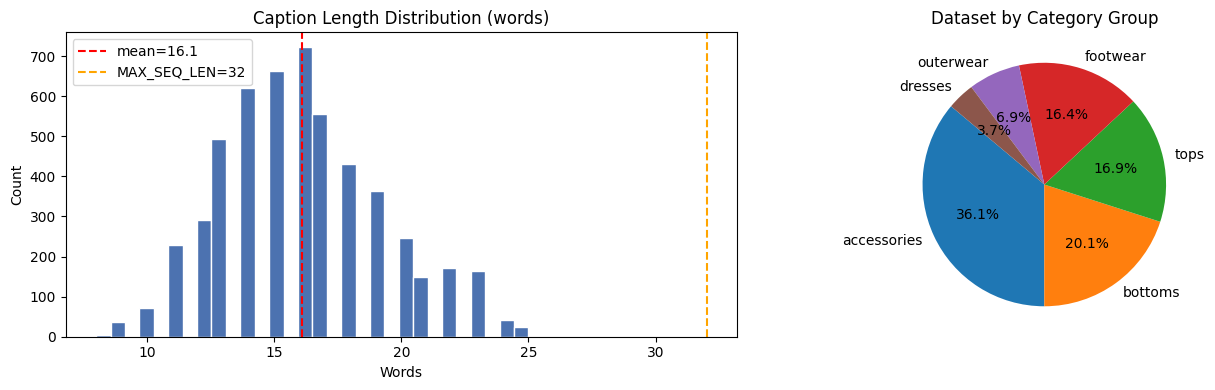

Caption length stats:
count    5281.00
mean       16.10
std         3.22
min         8.00
25%        14.00
50%        16.00
75%        18.00
max        25.00
Name: caption, dtype: float64

Captions exceeding MAX_SEQ_LEN=32: 0 (0.0%)


In [7]:
# ── Caption length distribution ────────────────────────────────────────────
caption_lengths = df["caption"].apply(lambda c: len(c.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(caption_lengths, bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(caption_lengths.mean(), color="red", linestyle="--",
                label=f"mean={caption_lengths.mean():.1f}")
axes[0].axvline(MAX_SEQ_LEN, color="orange", linestyle="--",
                label=f"MAX_SEQ_LEN={MAX_SEQ_LEN}")
axes[0].set_title("Caption Length Distribution (words)")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].pie(df["category_group"].value_counts().values,
            labels=df["category_group"].value_counts().index,
            autopct="%1.1f%%", startangle=140)
axes[1].set_title("Dataset by Category Group")

plt.tight_layout()
plt.show()

print(f"Caption length stats:\n{caption_lengths.describe().round(2)}")
print(f"\nCaptions exceeding MAX_SEQ_LEN={MAX_SEQ_LEN}: "
    f"{(caption_lengths > MAX_SEQ_LEN).sum():,} "
    f"({(caption_lengths > MAX_SEQ_LEN).mean()*100:.1f}%)")

## Section 4 — Tokenizer & Vocabulary

We use Keras `Tokenizer` to build the vocabulary from all captions.  
Special tokens: `<pad>=0`, `<start>`, `<end>`, `<unk>` are reserved.


In [8]:
# ── Build tokenizer ────────────────────────────────────────────────────────
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=UNK_TOKEN,
    filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n',
    lower=True
)

tokenizer.fit_on_texts(df["caption"].tolist())

# Vocabulary stats
word_index  = tokenizer.word_index
vocab_size  = min(len(word_index) + 1, VOCAB_SIZE)
index_word  = {v: k for k, v in word_index.items()}

print(f"Vocabulary size (full)     : {len(word_index):,}")
print(f"Vocabulary size (capped)   : {vocab_size:,}")
print()

# Token IDs for special tokens
START_ID = tokenizer.word_index.get(START_TOKEN, 1)
END_ID   = tokenizer.word_index.get(END_TOKEN,   2)
UNK_ID   = tokenizer.word_index.get(UNK_TOKEN,   3)
PAD_ID   = 0

print(f"START_TOKEN id : {START_ID}")
print(f"END_TOKEN id   : {END_ID}")
print(f"UNK_TOKEN id   : {UNK_ID}")
print(f"PAD_TOKEN id   : {PAD_ID}  (implicit)")

# Save tokenizer
tokenizer_path = MODELS_DIR / "tokenizer.json"
tokenizer_json = tokenizer.to_json()
with open(tokenizer_path, "w") as f:
    json.dump(tokenizer_json, f)
print(f"\nTokenizer saved → {tokenizer_path}")

Vocabulary size (full)     : 3,836
Vocabulary size (capped)   : 3,837

START_TOKEN id : 2
END_TOKEN id   : 4
UNK_TOKEN id   : 1
PAD_TOKEN id   : 0  (implicit)

Tokenizer saved → saved_models\tokenizer.json


In [9]:
# ── Encode all captions ────────────────────────────────────────────────────
sequences  = tokenizer.texts_to_sequences(df["caption"].tolist())
padded_seq = pad_sequences(sequences, maxlen=MAX_SEQ_LEN,
                        padding="post", truncating="post")

df["caption_seq"] = list(padded_seq)

print(f"Padded sequences shape : {padded_seq.shape}")
print()
print("Sample encoding:")
for i in range(3):
    print(f"  Caption  : {df['caption'].iloc[i]}")
    print(f"  Tokens   : {padded_seq[i][:15]}  ...")
    print()

Padded sequences shape : (5281, 32)

Sample encoding:
  Caption  : <start> Decathlon Women's Relaxation Yoga Fleece Sweatshirt - Mottled Grey mottled grey hoodies & sweatshirts women premium egp 1049.0 <end>
  Tokens   : [   2 1172   24 2299 1668  688   36 1669   58 1669   58   19   20    6
   13]  ...

  Caption  : <start> Decathlon Women's Fitness Sweatshirt 100 - Pink pink hoodies & sweatshirts women mid-range egp 699.0 <end>
  Tokens   : [   2 1172   24 1375   36  297  111  111   19   20    6    8    9    3
  176]  ...

  Caption  : <start> Decathlon Women's Fitness Hoodie 520 - Pink Quartz pink quartz hoodies & sweatshirts women premium egp 1739.0 <end>
  Tokens   : [   2 1172   24 1375   55  862  111  102  111  102   19   20    6   13
    3]  ...



## Section 5 — Image Loading & CNN Feature Extractors

### 5.1 Image Loading Utilities
Images are loaded from local disk (downloaded by `image_preprocessing.ipynb`).  
If an image file is missing, we fall back to downloading from `img_url`.


In [10]:
def load_image_from_disk(product_id, img_dir=IMG_DIR,
                        img_size=IMG_SIZE) -> np.ndarray:
    """
    Load a single image by product_id.
    Returns: float32 numpy array of shape (H, W, 3), pixel values in [0,1].
    Falls back to a grey placeholder if file not found.
    """
    path = Path(img_dir) / f"{product_id}.jpg"
    try:
        if path.exists():
            with Image.open(path) as img:
                img = img.convert("RGB").resize(img_size, Image.BILINEAR)
                return np.array(img, dtype=np.float32) / 255.0
        else:
            # Placeholder — grey image
            return np.ones((*img_size, 3), dtype=np.float32) * 0.5
    except Exception:
        return np.ones((*img_size, 3), dtype=np.float32) * 0.5


def load_image_from_url(url: str, img_size=IMG_SIZE) -> np.ndarray:
    """Download an image from URL and return preprocessed array."""
    try:
        resp = requests.get(url, timeout=10)
        img  = Image.open(BytesIO(resp.content)).convert("RGB")
        img  = img.resize(img_size, Image.BILINEAR)
        return np.array(img, dtype=np.float32) / 255.0
    except Exception:
        return np.ones((*img_size, 3), dtype=np.float32) * 0.5


def preprocess_for_resnet(img: np.ndarray) -> np.ndarray:
    """Apply ResNet50 / ResNet50V2 preprocessing (per-channel mean subtraction)."""
    img = img * 255.0  # back to [0,255]
    return tf.keras.applications.resnet_v2.preprocess_input(img)


def preprocess_for_efficientnet(img: np.ndarray) -> np.ndarray:
    """EfficientNet expects [0,255] uint8-range float."""
    img = img * 255.0
    return tf.keras.applications.efficientnet.preprocess_input(img)

print("Image loading utilities defined ✅")

Image loading utilities defined ✅


### 5.2 CNN Architecture Deep-Dive

#### Why pretrained CNNs?
ImageNet-pretrained CNNs already encode low-level features (edges, textures) and  
high-level features (shapes, object parts) in their intermediate layers.  
Freezing early layers and fine-tuning later ones transfers visual knowledge to fashion.

#### Feature extraction strategy
| Model | Extraction Layer | Output Shape | Feature Dim |
|---|---|---|---|
| ResNet50V2 | `post_bn` (before avg_pool) | `(7,7,2048)` | 2048 (after GAP) |
| ResNet50 | `avg_pool` | `(1,1,2048)` → squeeze | 2048 |
| EfficientNetB0 | `top_activation` | `(7,7,1280)` → GAP | 1280 |

The spatial feature maps `(7×7×C)` preserve spatial information that attention can use.  
Global Average Pooling then produces a fixed-length vector for the RNN initial state.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CNN FEATURE EXTRACTOR BUILDERS
# Each returns a Keras Model that:
#   input  : (batch, 224, 224, 3)   float32, preprocessed
#   output : (batch, feature_dim)   or spatial (batch, 49, feature_dim)
# ══════════════════════════════════════════════════════════════════════════════

def build_resnet50v2_extractor(spatial=False):
    """
    ResNet50V2 feature extractor.
    
    Architecture:
    Input (224,224,3)
        └─ ResNet50V2 backbone (pretrained ImageNet)
            └─ 'post_bn' layer  →  spatial (7,7,2048)
                └─ GlobalAveragePooling2D  →  vector (2048,)
    
    Key layer: 'post_bn' is the batch-norm AFTER the final residual block,
    BEFORE the classification head. It retains rich spatial semantics.
    
    spatial=True  → returns (batch, 49, 2048)  [for spatial attention]
    spatial=False → returns (batch, 2048)       [for state initialisation]
    """
    base = ResNet50V2(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, IMG_CHANNELS)
    )
    
    # Freeze all but the last 30 layers (fine-tune top)
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    
    inp = base.input  # (batch, 224, 224, 3)
    
    # Spatial feature map: (batch, 7, 7, 2048)
    spatial_feat = base.get_layer("post_bn").output
    
    if spatial:
        # Reshape to (batch, 49, 2048) for attention
        spatial_out = layers.Reshape((49, 2048))(spatial_feat)
        return Model(inp, spatial_out, name="ResNet50V2_spatial")
    else:
        vec = layers.GlobalAveragePooling2D()(spatial_feat)
        return Model(inp, vec, name="ResNet50V2_vector")


def build_resnet50_extractor(spatial=False):
    """
    ResNet50 feature extractor.
    
    Architecture:
    Input (224,224,3)
        └─ ResNet50 backbone (pretrained ImageNet)
            └─ 'conv5_block3_out' →  spatial (7,7,2048)
                └─ GlobalAveragePooling2D  →  vector (2048,)
    
    'conv5_block3_out' is the output of the final residual block.
    This gives a 7×7 spatial grid, each cell encoding a 2048-dim feature.
    """
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, IMG_CHANNELS)
    )
    
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True
    
    inp = base.input
    spatial_feat = base.get_layer("conv5_block3_out").output  # (7,7,2048)
    
    if spatial:
        spatial_out = layers.Reshape((49, 2048))(spatial_feat)
        return Model(inp, spatial_out, name="ResNet50_spatial")
    else:
        vec = layers.GlobalAveragePooling2D()(spatial_feat)
        return Model(inp, vec, name="ResNet50_vector")


def build_efficientnetb0_extractor(spatial=False):
    """
    EfficientNetB0 feature extractor.
    
    Architecture:
    Input (224,224,3)
        └─ EfficientNetB0 backbone (pretrained ImageNet)
            └─ 'top_activation' layer  →  spatial (7,7,1280)
                └─ GlobalAveragePooling2D  →  vector (1280,)
    
    'top_activation' is the activation after the final MBConv block,
    before the classification head. Feature dimension is 1280.
    EfficientNetB0 is more parameter-efficient than ResNets.
    """
    base = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, IMG_CHANNELS)
    )
    
    for layer in base.layers[:-20]:
        layer.trainable = False
    for layer in base.layers[-20:]:
        layer.trainable = True

    inp          = base.input
    spatial_feat = base.get_layer("top_activation").output  # (7,7,1280)

    if spatial:
        spatial_out = layers.Reshape((49, 1280))(spatial_feat)
        return Model(inp, spatial_out, name="EfficientNetB0_spatial")
    else:
        vec = layers.GlobalAveragePooling2D()(spatial_feat)
        return Model(inp, vec, name="EfficientNetB0_vector")

print("CNN extractor builders defined ✅")
print()
# Quick shape check
resnet50v2_vec = build_resnet50v2_extractor(spatial=False)
resnet50_vec   = build_resnet50_extractor(spatial=False)
effnet_vec     = build_efficientnetb0_extractor(spatial=False)

dummy = tf.zeros((1, 224, 224, 3))
print(f"ResNet50V2  vector output : {resnet50v2_vec(dummy).shape}")
print(f"ResNet50    vector output : {resnet50_vec(dummy).shape}")
print(f"EfficientNetB0 vec output : {effnet_vec(dummy).shape}")

del resnet50v2_vec, resnet50_vec, effnet_vec  # free memory

CNN extractor builders defined ✅

ResNet50V2  vector output : (1, 2048)
ResNet50    vector output : (1, 2048)
EfficientNetB0 vec output : (1, 1280)


## Section 6 — Train/Val/Test Split & `tf.data` Pipeline

### Why tf.data?
- Loads images lazily — no RAM overload
- Applies augmentation on the fly
- Prefetches batches for GPU utilization


In [12]:
# ── Filter rows that have a valid image on disk ────────────────────────────
def has_image(row):
    return (IMG_DIR / f"{row['product_id']}.jpg").exists()

# If IMG_DIR is empty / images not downloaded, ALL rows will be used
# (images will return placeholder) — useful for code testing
img_exists = df.apply(has_image, axis=1)
n_with_img = img_exists.sum()
print(f"Rows with image on disk : {n_with_img:,} / {len(df):,}")

if n_with_img < 100:
    print("  Few/no images found on disk.")
    print("   Images will be loaded from img_url OR grey placeholders will be used.")
    print("   Set IMG_DIR to your actual images folder for best results.")
    df_model = df.copy()
else:
    df_model = df[img_exists].copy()

df_model = df_model.reset_index(drop=True)
print(f"\nRows used for modelling : {len(df_model):,}")


Rows with image on disk : 5,270 / 5,281

Rows used for modelling : 5,270


In [13]:
# ── Train / Val / Test split ───────────────────────────────────────────────
indices = np.arange(len(df_model))
train_idx, temp_idx = train_test_split(indices, test_size=(1-TRAIN_SPLIT),
                                        random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.5,
                                        random_state=SEED)

df_train = df_model.iloc[train_idx].reset_index(drop=True)
df_val   = df_model.iloc[val_idx].reset_index(drop=True)
df_test  = df_model.iloc[test_idx].reset_index(drop=True)

print(f"Train : {len(df_train):,}  ({len(df_train)/len(df_model)*100:.1f}%)")
print(f"Val   : {len(df_val):,}  ({len(df_val)/len(df_model)*100:.1f}%)")
print(f"Test  : {len(df_test):,}  ({len(df_test)/len(df_model)*100:.1f}%)")


Train : 4,216  (80.0%)
Val   : 527  (10.0%)
Test  : 527  (10.0%)


In [14]:
# ── Oversample rare categories in TRAIN ONLY ──────────────────────────────
from sklearn.utils import resample

RARE_GROUPS       = ["dresses", "outerwear"]
OVERSAMPLE_FACTOR = 2

print("Balancing training set ...")
print(f"  Rare groups to oversample (×{OVERSAMPLE_FACTOR}): {RARE_GROUPS}")
print()

train_parts = [df_train]
for grp in RARE_GROUPS:
    subset = df_train[df_train["category_group"] == grp]
    if len(subset) == 0:
        print(f"  ⚠️  '{grp}' not found in train split — skipping")
        continue
    oversampled = resample(subset, replace=True,
                           n_samples=len(subset) * OVERSAMPLE_FACTOR,
                        random_state=SEED)
    train_parts.append(oversampled)
    print(f"  {grp:<15} : {len(subset):,} → +{len(oversampled):,} extra samples")

df_train_balanced = (pd.concat(train_parts)
                    .sample(frac=1, random_state=SEED)
                    .reset_index(drop=True))

print()
print(f"Original train size  : {len(df_train):,}")
print(f"Balanced train size  : {len(df_train_balanced):,}")
print()
print("Balanced category_group distribution (train):")
print(df_train_balanced["category_group"].value_counts())

Balancing training set ...
  Rare groups to oversample (×2): ['dresses', 'outerwear']

  dresses         : 150 → +300 extra samples
  outerwear       : 292 → +584 extra samples

Original train size  : 4,216
Balanced train size  : 5,100

Balanced category_group distribution (train):
category_group
accessories    1500
outerwear       876
bottoms         866
tops            717
footwear        691
dresses         450
Name: count, dtype: int64


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# tf.data PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

# Data Augmentation layers (applied ONLY during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")


def make_tf_dataset(df_split: pd.DataFrame,
                    cnn_preprocess_fn,
                    augment: bool = False,
                    batch_size: int = BATCH_SIZE,
                    shuffle: bool = True) -> tf.data.Dataset:
    """
    Build a tf.data.Dataset that yields:
        ( [image, input_caption], target_caption )

    Format required by model.fit() for 2-input Functional API models.

    Teacher forcing:
    input_caption  = <start> w1 w2 ... wN-1
    target_caption =         w1 w2 ... wN <end>
    """
    product_ids = df_split["product_id"].values
    captions    = np.array(list(df_split["caption_seq"]), dtype=np.int32)

    def load_image_tf(product_id):
        """Load image inside tf.py_function."""
        def _load(pid):
            pid = pid.numpy()
            img = load_image_from_disk(pid)
            img = cnn_preprocess_fn(img * 255.0)
            return img.astype(np.float32)
        return tf.py_function(_load, [product_id], tf.float32)

    def parse_fn(product_id, caption_seq):
        img = load_image_tf(product_id)
        img.set_shape([*IMG_SIZE, IMG_CHANNELS])

        # Teacher forcing split
        input_cap  = caption_seq[:-1]     # <start> ... wN-1
        target_cap = caption_seq[1:]      # w1 ... <end>

        # Pad to MAX_SEQ_LEN - 1
        tgt_len    = MAX_SEQ_LEN - 1
        input_cap  = tf.cast(tf.pad(input_cap,
                    [[0, tgt_len - tf.shape(input_cap)[0]]]), tf.int32)
        target_cap = tf.cast(tf.pad(target_cap,
                    [[0, tgt_len - tf.shape(target_cap)[0]]]), tf.int32)

        # ── Return ([image, caption], target) for model.fit() ────────────
        return (img, input_cap), target_cap

    def augment_fn(inputs, target_cap):
        img, input_cap = inputs
        img = data_augmentation(img[tf.newaxis], training=True)[0]
        return (img, input_cap), target_cap

    ds = tf.data.Dataset.from_tensor_slices(
        (product_ids.astype(np.int64), captions)
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(2000, len(df_split)), seed=SEED)
    ds = ds.map(parse_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


print("tf.data pipeline builder defined ✅")
print()
print("Preprocessing functions will be assigned per model:")
print("  ResNet50V2 / ResNet50   →  resnet_v2.preprocess_input")
print("  EfficientNetB0          →  efficientnet.preprocess_input")
print()
print("Dataset output format: ([image, caption], target)  ✅")

tf.data pipeline builder defined ✅

Preprocessing functions will be assigned per model:
  ResNet50V2 / ResNet50   →  resnet_v2.preprocess_input
  EfficientNetB0          →  efficientnet.preprocess_input

Dataset output format: ([image, caption], target)  ✅


In [16]:
# ── Preprocessing functions ───────────────────────────────────────────────
resnet_preproc = tf.keras.applications.resnet_v2.preprocess_input
effnet_preproc = tf.keras.applications.efficientnet.preprocess_input

# Build all datasets using BALANCED train split
train_ds_resnet = make_tf_dataset(df_train_balanced, resnet_preproc, augment=True)
val_ds_resnet   = make_tf_dataset(df_val,            resnet_preproc, augment=False, shuffle=False)

train_ds_effnet = make_tf_dataset(df_train_balanced, effnet_preproc, augment=True)
val_ds_effnet   = make_tf_dataset(df_val,            effnet_preproc, augment=False, shuffle=False)

test_ds_resnet  = make_tf_dataset(df_test, resnet_preproc, augment=False, shuffle=False)
test_ds_effnet  = make_tf_dataset(df_test, effnet_preproc, augment=False, shuffle=False)

print("All datasets built ✅")
print(f"  Train batches (balanced) : {len(train_ds_resnet)}")
print(f"  Val batches              : {len(val_ds_resnet)}")
print(f"  Test batches             : {len(test_ds_resnet)}")

All datasets built ✅
  Train batches (balanced) : 319
  Val batches              : 33
  Test batches             : 33


## Section 7 — Attention Mechanism & Transformer Decoder

### Why Attention?
In standard encoder-decoder captioning, the RNN receives a **single** CNN vector as context.  
This is a bottleneck — all spatial image information is compressed into one fixed vector.

**Bahdanau Attention** solves this:
1. The CNN extracts a **spatial** feature map: `(49, feature_dim)` — one vector per 7×7 grid cell
2. At each decoding step, the attention module **weighs** each spatial location
3. High weights → regions relevant to the next word (e.g. collar area → "long sleeve")
4. The weighted sum is the dynamic context vector fed to the RNN

**Transformer Decoder** generalises this to multi-head self-attention + cross-attention:
- Self-attention: each token attends to all previous tokens
- Cross-attention: each token attends to all image spatial features


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# BAHDANAU ATTENTION (for LSTM / GRU decoders)
# ══════════════════════════════════════════════════════════════════════════════

class BahdanauAttention(layers.Layer):
    """
    Computes additive attention between decoder hidden state and
    CNN spatial feature map.
    
    Steps:
    1.Project image features  : W1 * features  → (B, 49, attn_units)
    2. Project decoder state   : W2 * hidden    → (B, 1, attn_units)
    3. Add & tanh              : tanh(step1 + step2)
    4. Score projection        : V * tanh(...)  → (B, 49, 1)
    5. Softmax                 : attention weights (B, 49, 1)
    6. Weighted sum            : context = sum(weights * features) → (B, feature_dim)
    
    Why tanh? It acts as a non-linear gate combining image & text signals.
    Why V (1-unit projection)? It collapses to a scalar score per spatial location.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = layers.Dense(units)   # project image features
        self.W2 = layers.Dense(units)   # project decoder state
        self.V  = layers.Dense(1)       # scalar score per location

    def call(self, features, hidden):
        """
        features : (B, 49, feature_dim)
        hidden   : (B, units)  — RNN hidden state
        returns  : context (B, feature_dim), attention_weights (B, 49, 1)
        """
        hidden_expanded = tf.expand_dims(hidden, 1)        # (B, 1, units)
        score = self.V(tf.nn.tanh(
            self.W1(features) + self.W2(hidden_expanded)   # (B, 49, units)
        ))                                                  # (B, 49, 1)
        attention_weights = tf.nn.softmax(score, axis=1)   # (B, 49, 1)
        context_vector    = attention_weights * features    # (B, 49, feature_dim)
        context_vector    = tf.reduce_sum(context_vector, axis=1)  # (B, feature_dim)
        return context_vector, attention_weights


print("BahdanauAttention defined ✅")

BahdanauAttention defined ✅


## Section 8 — Model 1: ResNet50V2 + LSTM + Bahdanau Attention

### Architecture Explanation

```
Image (224×224×3)
  └─ ResNet50V2 backbone  →  spatial features (7×7×2048) → reshape → (49, 2048)
       └─ Feature projection Dense(512)  →  (49, 512)
            └─ BahdanauAttention(context + LSTM hidden state)  →  context (512,)
                 └─ LSTM(512)  ←  [word_embedding ++ context_vector]
                      └─ Dense(vocab_size) → softmax → next_word probability
```

**Layer-by-layer tensor flow:**

| Layer | Input shape | Output shape | Purpose |
|---|---|---|---|
| Input image | `(B,224,224,3)` | — | RGB image |
| ResNet50V2 | `(B,224,224,3)` | `(B,7,7,2048)` | Visual feature extraction |
| Reshape | `(B,7,7,2048)` | `(B,49,2048)` | Flatten spatial grid |
| Dense projection | `(B,49,2048)` | `(B,49,512)` | Reduce feature dim for attention |
| Embedding | `(B,seq)` | `(B,seq,256)` | Map tokens to dense vectors |
| LSTM | `(B,256+512)` | `(B,512)` | Sequence decoding |
| BahdanauAttention | features+hidden | `(B,512)` | Dynamic image context |
| Dense output | `(B,512)` | `(B,vocab)` | Word probability distribution |


In [19]:
def build_model1_resnet50v2_lstm(
        vocab_size   = vocab_size,
        embed_dim    = EMBED_DIM,
        units        = UNITS,
        attn_units   = ATTN_UNITS,
        dropout_rate = DROPOUT_RATE,
        feature_dim  = 2048,
) -> Model:
    """
    Model 1: ResNet50V2 (spatial) + Bahdanau Attention + LSTM
    Uses TensorFlow Functional API for explicit multi-input architecture.
    """
    # ── INPUT HEADS ─────────────────────────────────────────────────────────
    img_input     = Input(shape=(*IMG_SIZE, IMG_CHANNELS), name="image_input")
    caption_input = Input(shape=(MAX_SEQ_LEN - 1,),        name="caption_input")

    # ── CNN ENCODER ──────────────────────────────────────────────────────────
    cnn_backbone = build_resnet50v2_extractor(spatial=True)  # (B,49,2048)
    spatial_features = cnn_backbone(img_input)               # (B,49,2048)

    # Project to smaller dim to reduce memory & computation
    spatial_features = layers.Dense(
        units, activation="relu",
        kernel_regularizer=l2(1e-4), name="feature_projection"
    )(spatial_features)                                       # (B,49,512)
    spatial_features = layers.Dropout(dropout_rate)(spatial_features)

    # Pool to initialise LSTM hidden state
    init_state = layers.GlobalAveragePooling1D(name="global_pool")(spatial_features)  # (B,512)
    init_state = layers.Dense(units, activation="tanh", name="init_hidden")(init_state)
    init_carry = layers.Dense(units, activation="tanh", name="init_carry")(init_state)

    # ── TEXT ENCODER ─────────────────────────────────────────────────────────
    word_emb = layers.Embedding(vocab_size, embed_dim,
                                mask_zero=True, name="word_embedding")(caption_input)
    # (B, seq_len, embed_dim)

    # ── DECODER LOOP (unrolled with Functional API) ───────────────────────────
    # We use a custom step-by-step loop via a custom layer
    # For simplicity: concat context to each timestep, then LSTM
    # Note: True step-by-step attention requires a custom training loop.
    # Here we use a spatial-attention-pooled context + LSTM for Functional API compatibility.

    attention_layer = BahdanauAttention(units, name="bahdanau_attention")

    # Compute initial context using init_state
    context, attn_weights = attention_layer(spatial_features, init_state)
    context_expanded = layers.RepeatVector(MAX_SEQ_LEN - 1)(context)  # (B, seq, 512)

    # Concatenate word embeddings with attended context
    decoder_input = layers.Concatenate(axis=-1, name="decoder_input")(
        [word_emb, context_expanded])  # (B, seq, embed+512)

    # LSTM decoder
    lstm_out = layers.LSTM(
        units,
        return_sequences=True,
        dropout=dropout_rate,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-4),
        name="lstm_decoder"
    )(decoder_input, initial_state=[init_state, init_carry])
    # (B, seq, 512)

    # BatchNorm + Dropout for regularisation
    lstm_out = layers.BatchNormalization(name="bn_lstm")(lstm_out)
    lstm_out = layers.Dropout(dropout_rate)(lstm_out)

    # Output projection
    output = layers.Dense(
        vocab_size, activation="softmax",
        kernel_regularizer=l2(1e-4),
        name="output_softmax"
    )(lstm_out)  # (B, seq, vocab_size)

    model = Model(
        inputs=[img_input, caption_input],
        outputs=output,
        name="Model1_ResNet50V2_LSTM_Attention"
    )
    return model


model1 = build_model1_resnet50v2_lstm()
model1.compile(
    optimizer=Adam(learning_rate=LR, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.summary()


Model: "Model1_ResNet50V2_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet50V2_spatial  │ (None, 49, 2048)  │ 23,564,800 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 49, 512)   │  1,049,088 │ ResNet50V2_spati… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 512)   │          0 │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 512)       │          0 │ dropout[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_hidden (Dense) │ (None, 512)       │    262,656 │ global_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 31, 256)   │    982,272 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 512),     │    525,825 │ dropout[0][0],    │
│ (BahdanauAttention) │ (None, 49, 1)]    │            │ init_hidden[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 31)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 31, 512)   │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 31, 1)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 31, 256)   │          0 │ word_embedding[0… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 31, 256)   │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 31, 512)   │          0 │ repeat_vector[0]… │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 31, 768)   │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_carry (Dense)  │ (None, 512)       │    262,656 │ init_hidden[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 31, 768)   │          0 │ logical_or[0][0]

 Total params: 31,241,214 (119.18 MB)

 Trainable params: 22,118,910 (84.38 MB)

 Non-trainable params: 9,122,304 (34.80 MB)

## Section 9 — Model 2: ResNet50 + GRU + Bahdanau Attention

### Architecture Explanation

GRU is a lighter alternative to LSTM — it has **2 gates** (reset + update) vs LSTM's 3 (input, forget, output).  
GRU trains faster and can match LSTM performance on many tasks.

```
Image (224×224×3)
  └─ ResNet50 backbone  →  (7×7×2048) → reshape → (49, 2048)
       └─ Dense(256)  →  (49, 256)
            └─ BahdanauAttention  →  context (256,)
                 └─ GRU(512)  ←  [word_emb ++ context]
                      └─ Dense(vocab_size)
```

**Difference from Model 1:**
- CNN backbone: ResNet50 (original) vs ResNet50V2 (improved batch-norm positioning)
- RNN: GRU vs LSTM — fewer parameters, faster convergence
- Initialisation: GRU has only one state vector vs LSTM's (h, c) pair


In [20]:
def build_model2_resnet50_gru(
        vocab_size   = vocab_size,
        embed_dim    = EMBED_DIM,
        units        = UNITS,
        attn_units   = ATTN_UNITS,
        dropout_rate = DROPOUT_RATE,
) -> Model:
    """
    Model 2: ResNet50 (spatial) + Bahdanau Attention + GRU
    """
    img_input     = Input(shape=(*IMG_SIZE, IMG_CHANNELS), name="image_input")
    caption_input = Input(shape=(MAX_SEQ_LEN - 1,),        name="caption_input")

    # CNN encoder
    cnn_backbone     = build_resnet50_extractor(spatial=True)
    spatial_features = cnn_backbone(img_input)    # (B,49,2048)
    spatial_features = layers.Dense(
        units, activation="relu",
        kernel_regularizer=l2(1e-4), name="feature_projection"
    )(spatial_features)                           # (B,49,512)
    spatial_features = layers.Dropout(dropout_rate)(spatial_features)

    init_state = layers.GlobalAveragePooling1D()(spatial_features)
    init_state = layers.Dense(units, activation="tanh", name="gru_init")(init_state)

    # Word embedding
    word_emb = layers.Embedding(vocab_size, embed_dim,
                                mask_zero=True, name="word_embedding")(caption_input)

    # Attention context (initial pass)
    attention_layer = BahdanauAttention(units, name="bahdanau_attention")
    context, _      = attention_layer(spatial_features, init_state)
    context_exp     = layers.RepeatVector(MAX_SEQ_LEN - 1)(context)

    decoder_input = layers.Concatenate(axis=-1)([word_emb, context_exp])

    # GRU decoder — single state (simpler than LSTM)
    gru_out = layers.GRU(
        units,
        return_sequences=True,
        dropout=dropout_rate,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(1e-4),
        name="gru_decoder"
    )(decoder_input, initial_state=init_state)   # (B, seq, 512)

    gru_out = layers.BatchNormalization(name="bn_gru")(gru_out)
    gru_out = layers.Dropout(dropout_rate)(gru_out)

    # Additional dense layer for richer representation
    gru_out = layers.Dense(units // 2, activation="relu",
                        name="intermediate_dense")(gru_out)

    output = layers.Dense(
        vocab_size, activation="softmax",
        name="output_softmax"
    )(gru_out)

    model = Model(
        inputs=[img_input, caption_input],
        outputs=output,
        name="Model2_ResNet50_GRU_Attention"
    )
    return model


model2 = build_model2_resnet50_gru()
model2.compile(
    optimizer=Adam(learning_rate=LR, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()


Model: "Model2_ResNet50_GRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet50_spatial    │ (None, 49, 2048)  │ 23,587,712 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 49, 512)   │  1,049,088 │ ResNet50_spatial… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 512)   │          0 │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ dropout_2[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_init (Dense)    │ (None, 512)       │    262,656 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 31, 256)   │    982,272 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 512),     │    525,825 │ dropout_2[0][0],  │
│ (BahdanauAttention) │ (None, 49, 1)]    │            │ gru_init[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 31)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 31, 512)   │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 31, 1)     │          0 │ not_equal_1[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_1        │ (None, 31, 256)   │          0 │ word_embedding[0… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 31, 256)   │          0 │ expand_dims_1[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_1         │ (None, 31, 512)   │          0 │ repeat_vector_1[… │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 31, 768)   │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 31, 768)   │          0 │ logical_or_1[0][… │
│ (Concatenate)       │                   │            │ ones_like_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 29,496,190 (112.52 MB)

 Trainable params: 20,357,630 (77.66 MB)

 Non-trainable params: 9,138,560 (34.86 MB)

## Section 12 — Training All Models

### Callbacks Used
- **EarlyStopping**: Monitors `val_loss`; stops after `patience` epochs without improvement. Restores best weights.
- **ReduceLROnPlateau**: Halves the learning rate when val_loss plateaus for `patience` epochs.
- **ModelCheckpoint**: Saves the best model weights to disk automatically.

### Regularisation Strategy
- **Dropout** (0.3): Randomly zero-activations prevent co-adaptation.
- **BatchNormalization**: Normalises layer inputs, speeds convergence, mild regularisation effect.
- **L2 weight decay** (1e-4): Penalises large weights in Dense layers.
- **Data Augmentation**: Horizontal flip, rotation, zoom, contrast — increases effective dataset size.

In [23]:
def get_callbacks(model_name: str, monitor="val_loss"):
    """Return standard callbacks for all models."""
    ckpt_path = str(MODELS_DIR / f"{model_name}_best.keras")
    return [
        EarlyStopping(
            monitor=monitor,
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor=monitor,
            save_best_only=True,
            verbose=1
        ),
    ]


def plot_history(history, model_name: str):
    """Plot training vs validation loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight="bold")

    axes[0].plot(history.history["loss"],     label="Train Loss", linewidth=2)
    axes[0].plot(history.history["val_loss"], label="Val Loss",   linewidth=2)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse CE Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if "accuracy" in history.history:
        axes[1].plot(history.history["accuracy"],     label="Train Acc", linewidth=2)
        axes[1].plot(history.history["val_accuracy"], label="Val Acc",   linewidth=2)
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(str(LOGS_DIR / f"{model_name}_history.png"), dpi=100)
    plt.show()
    print(f"  Best val_loss   : {min(history.history['val_loss']):.4f}")
    print(f"  Best val_acc    : {max(history.history.get('val_accuracy',[0])):.4f}")
    print(f"  Epochs run      : {len(history.history['loss'])}")


print("Callbacks & plotting helpers defined ✅")


Callbacks & plotting helpers defined ✅


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# BUILD tf.data DATASETS FOR ALL 3 MODELS
# ──────────────────────────────────────────────────────────────────────────────
# Training   : uses df_train_balanced (5,100 samples — oversampled rare classes)
# Validation : uses df_val (527 samples — pristine, no oversampling)
# Test       : uses df_test (527 samples — pristine, held out until evaluation)

# Preprocessing functions differ per CNN backbone:
#   ResNet50V2 / ResNet50   →  resnet_v2.preprocess_input  (mean subtraction)
#   EfficientNetB0          →  efficientnet.preprocess_input (scale to [-1,1])

# Augmentation applied to TRAIN only:
#   RandomFlip · RandomRotation · RandomZoom · RandomContrast
# ══════════════════════════════════════════════════════════════════════════════

train_ds_resnet = make_tf_dataset(df_train_balanced, resnet_preproc, augment=True)
val_ds_resnet   = make_tf_dataset(df_val, resnet_preproc, augment=False, shuffle=False)

train_ds_effnet = make_tf_dataset(df_train_balanced, effnet_preproc, augment=True)
val_ds_effnet   = make_tf_dataset(df_val, effnet_preproc, augment=False, shuffle=False)

test_ds_resnet  = make_tf_dataset(df_test, resnet_preproc, augment=False, shuffle=False)
test_ds_effnet  = make_tf_dataset(df_test, effnet_preproc, augment=False, shuffle=False)

print("All datasets built ✅")
print(f"  Train batches (balanced) : {len(train_ds_resnet)}")
print(f"  Val batches              : {len(val_ds_resnet)}")
print(f"  Test batches             : {len(test_ds_resnet)}")

All datasets built ✅
  Train batches (balanced) : 319
  Val batches              : 33
  Test batches             : 33


# Models Training:

# TRAIN MODEL 1: ResNet50V2 + LSTM + Attention


TRAINING MODEL 1: ResNet50V2 + LSTM + Attention
Epoch 1/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5704 - loss: 3.4836
Epoch 1: val_loss improved from None to 2.01539, saving model to saved_models\model1_resnet50v2_lstm_best.keras

Epoch 1: finished saving model to saved_models\model1_resnet50v2_lstm_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 674s 2s/step - accuracy: 0.6414 - loss: 2.4747 - val_accuracy: 0.6859 - val_loss: 2.0154 - learning_rate: 0.0010
Epoch 2/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7063 - loss: 1.7408
Epoch 2: val_loss improved from 2.01539 to 1.68553, saving model to saved_models\model1_resnet50v2_lstm_best.keras

Epoch 2: finished saving model to saved_models\model1_resnet50v2_lstm_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 801s 3s/step - accuracy: 0.7149 - loss: 1.6662 - val_accuracy: 0.7161 - val_loss: 1.6855 - learning_rate: 0.0010
Epoch 3/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7355 - loss: 1.4870
Epoch 3: val_loss impr

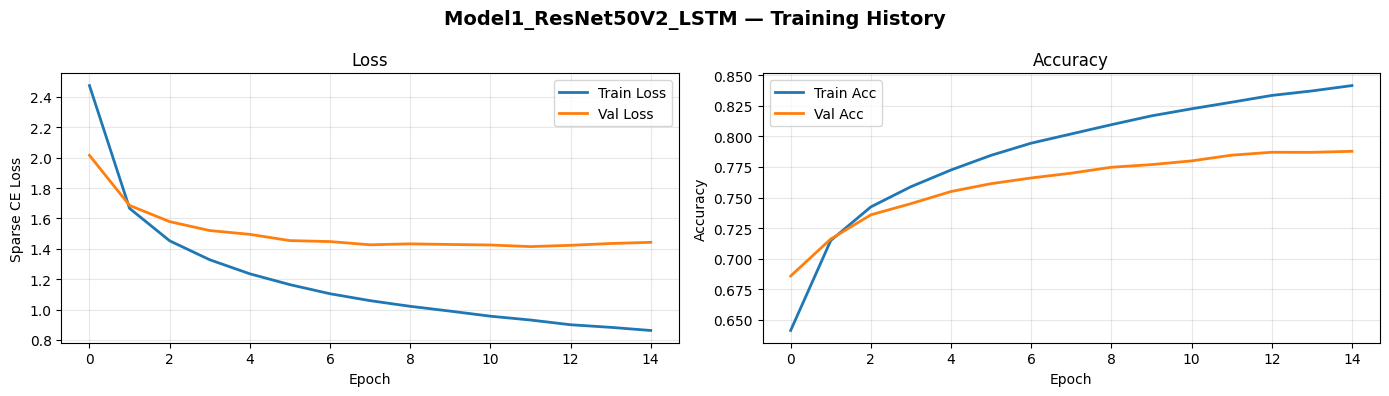

  Best val_loss   : 1.4145
  Best val_acc    : 0.7878
  Epochs run      : 15


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN MODEL 1: ResNet50V2 + LSTM + Attention
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("TRAINING MODEL 1: ResNet50V2 + LSTM + Attention")
print("=" * 60)

history1 = model1.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=EPOCHS,
    callbacks=get_callbacks("model1_resnet50v2_lstm"),
    verbose=1
)

plot_history(history1, "Model1_ResNet50V2_LSTM")


## load the saved model

In [27]:
import os
print(os.path.exists("saved_models/model1_resnet50v2_lstm_best.keras"))

True


In [25]:
from tensorflow.keras.models import load_model

model1_loaded = load_model(
    "saved_models/model1_resnet50v2_lstm_best.keras",
    custom_objects={
        "BahdanauAttention": BahdanauAttention
    }
)

print("Model loaded successfully ✅")
model1_loaded.summary()

Model loaded successfully ✅


Model: "Model1_ResNet50V2_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet50V2_spatial  │ (None, 49, 2048)  │ 23,564,800 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 49, 512)   │  1,049,088 │ ResNet50V2_spati… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 512)   │          0 │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 512)       │          0 │ dropout[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_hidden (Dense) │ (None, 512)       │    262,656 │ global_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 31, 256)   │    982,272 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 512),     │    525,825 │ dropout[0][0],    │
│ (BahdanauAttention) │ (None, 49, 1)]    │            │ init_hidden[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 31)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 31, 512)   │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 31, 1)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 31, 256)   │          0 │ word_embedding[0… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 31, 256)   │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 31, 512)   │          0 │ repeat_vector[0]… │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 31, 768)   │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_carry (Dense)  │ (None, 512)       │    262,656 │ init_hidden[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 31, 768)   │          0 │ logical_or[0][0]

 Total params: 75,479,036 (287.93 MB)

 Trainable params: 22,118,910 (84.38 MB)

 Non-trainable params: 9,122,304 (34.80 MB)

 Optimizer params: 44,237,822 (168.75 MB)

## MODEL 1 — INFERENCE & EVALUATION ON UNSEEN TEST DATA

✅ Model 1 loaded from disk
[1/8] ID=4460
  Actual   : Genuine Leather Belt For Men - Casual & Classic - Havan belts men budget egp 211
  Generated: venner women's hand bag with cross hand white white bags women mid range egp 349
  BLEU-1=0.062  BLEU-4=0.012

[2/8] ID=2030
  Actual   : Belts - Metal - Woman - Stylish and Durable Accessories belts women mid-range eg
  Generated: bracelets faux pearl decor glasses chain with a modern design chain with a sophi
  BLEU-1=0.095  BLEU-4=0.011

[3/8] ID=166
  Actual   : Carrot Fit High Waist Straight Leg Long Soft Jeans jeans women budget egp 225.0
  Generated: caesar boys' harem pants with side buttons and jeans pants kids mid range egp 30
  BLEU-1=0.125  BLEU-4=0.015

[4/8] ID=5621
  Actual   : Defacto Girl Crew Neck Oversize Fit Sweat Shirt - Ecru ecru hoodies & sweatshirt
  Generated: defacto girl relax fit crew neck long sleeve sweat shirt orange orange hoodies s
  BLEU-1=0.550  BLEU-4=0.044

[5/8] ID=727
  Actual   : Women's brown faux le

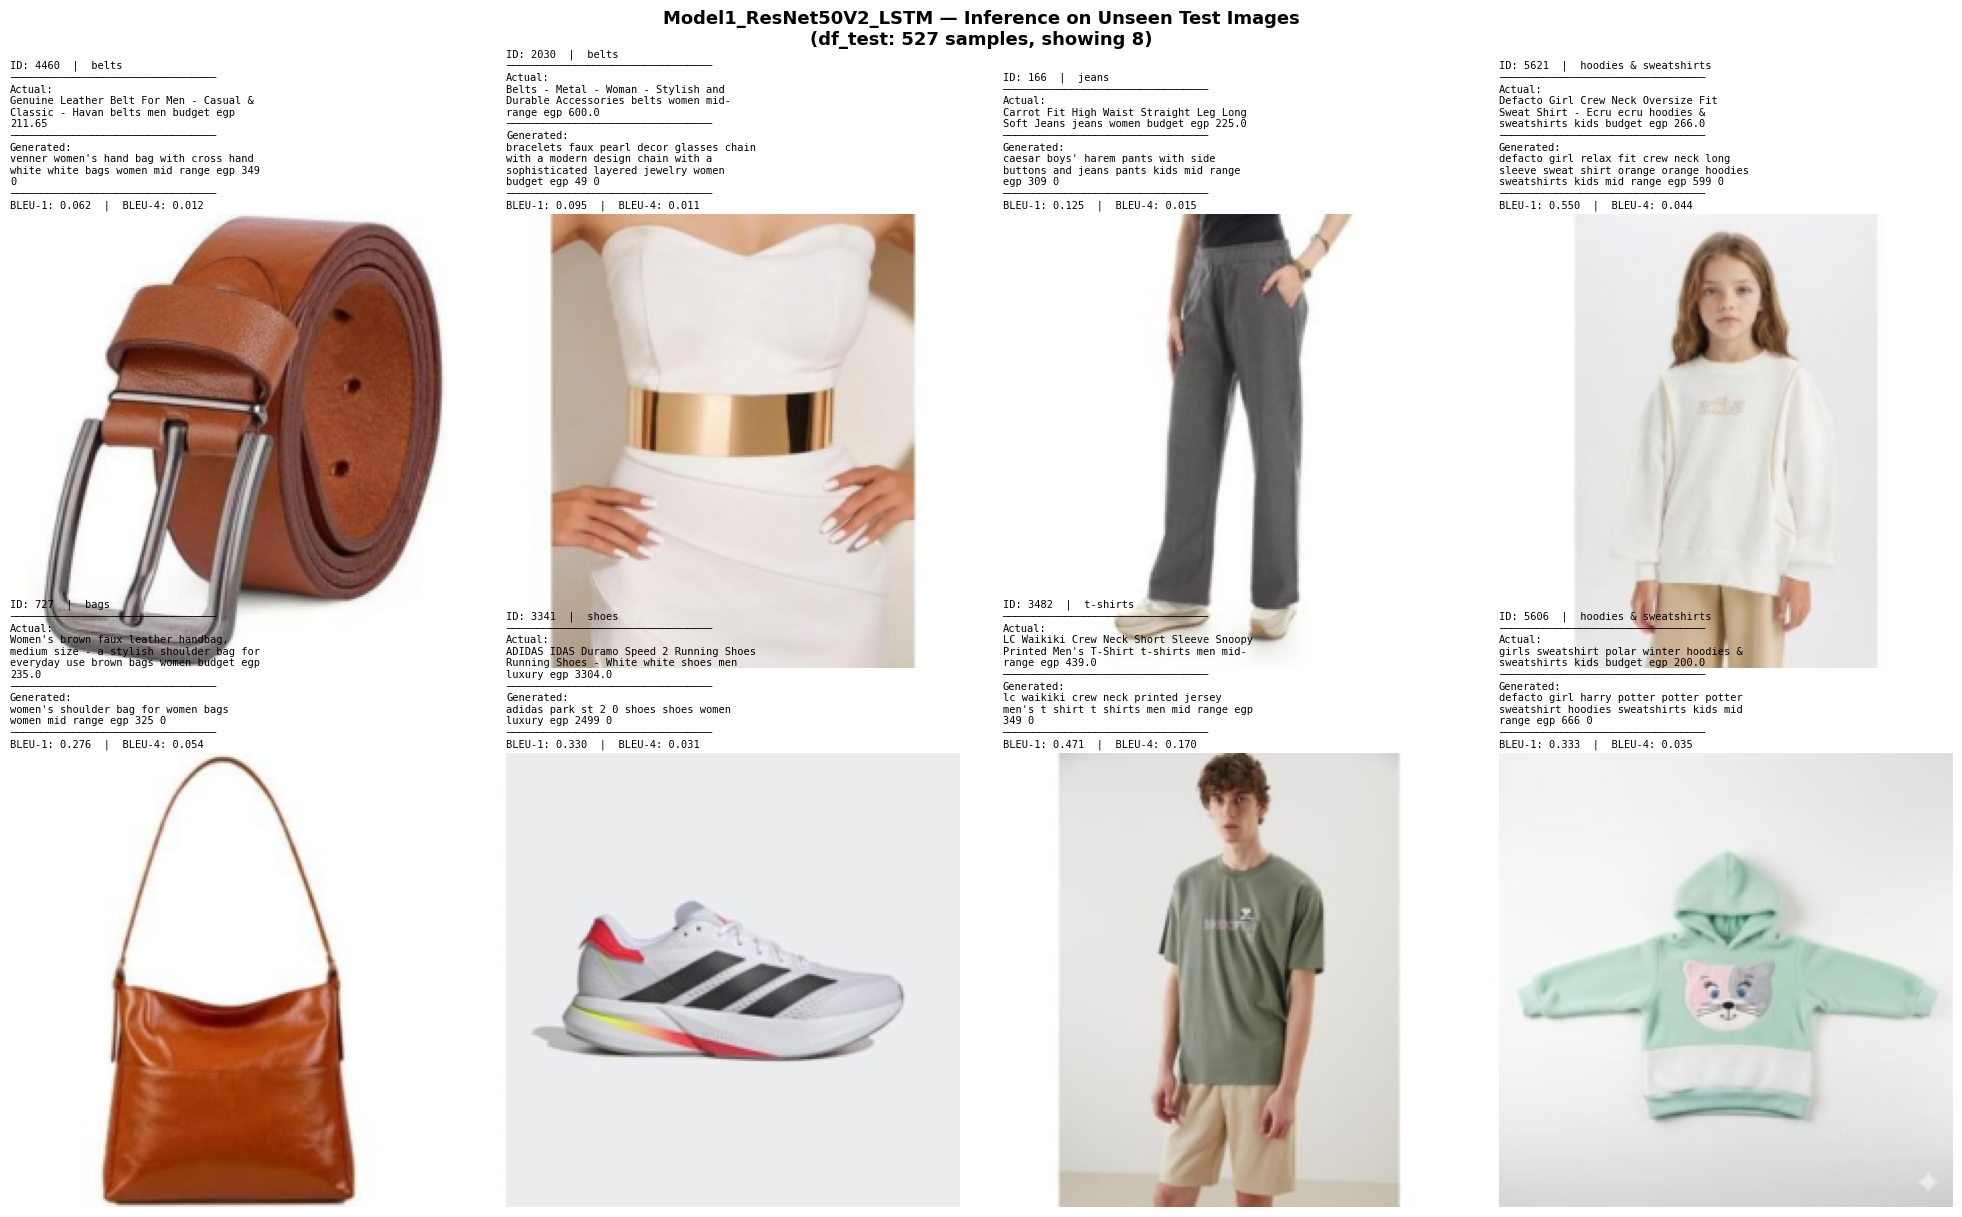

  Model1_ResNet50V2_LSTM — Test Set Summary
  Samples evaluated : 8
  Mean BLEU-1       : 0.2802
  Mean BLEU-4       : 0.0466


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1 — INFERENCE & EVALUATION ON UNSEEN TEST DATA
# ══════════════════════════════════════════════════════════════════════════════

import textwrap
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ── Load best saved model ─────────────────────────────────────────────────────
model1_loaded = tf.keras.models.load_model(
    str(MODELS_DIR / "model1_resnet50v2_lstm_best.keras"),
    custom_objects={"BahdanauAttention": BahdanauAttention}
)
print("✅ Model 1 loaded from disk")


# ── Greedy caption generator ──────────────────────────────────────────────────
def generate_caption_greedy(model, image_array, max_len=MAX_SEQ_LEN):
    """
    Auto-regressive greedy decoding.
    
    Steps:
    1. Preprocess image → (1,224,224,3)
    2. Start with [START_ID]
    3. At each step feed (image, current_sequence) → model → next token
    4. Append predicted token, repeat until END_ID or max_len
    """
    # Preprocess image for ResNet
    img = resnet_preproc(image_array * 255.0)
    img = np.expand_dims(img, 0)                    # (1,224,224,3)

    # Start token
    token_seq = [START_ID]

    for _ in range(max_len - 1):
        # Pad current sequence to MAX_SEQ_LEN - 1
        padded = pad_sequences(
            [token_seq],
            maxlen=MAX_SEQ_LEN - 1,
            padding="post"
        )                                            # (1, 31)

        # Forward pass
        preds = model.predict(
            [img, padded], verbose=0
        )                                            # (1, 31, vocab_size)

        # Get prediction at current position
        step    = min(len(token_seq) - 1, MAX_SEQ_LEN - 2)
        next_id = int(np.argmax(preds[0, step, :]))

        # Stop if END token predicted
        if next_id == END_ID:
            break

        token_seq.append(next_id)

    # Decode token ids → words
    words = []
    for tid in token_seq[1:]:                       # skip START
        word = index_word.get(tid, "")
        if word in (END_TOKEN, PAD_TOKEN, ""):
            break
        words.append(word)

    return " ".join(words)


# ── BLEU scorer ───────────────────────────────────────────────────────────────
def compute_bleu(reference: str, hypothesis: str) -> dict:
    """Compute BLEU-1 through BLEU-4 for a single caption pair."""
    sf  = SmoothingFunction().method1
    ref = reference.lower().split()
    hyp = hypothesis.lower().split()

    # Strip special tokens from reference
    ref = [w for w in ref if w not in
        (START_TOKEN, END_TOKEN, PAD_TOKEN)]

    return {
        "BLEU-1": sentence_bleu([ref], hyp, weights=(1,0,0,0),     smoothing_function=sf),
        "BLEU-2": sentence_bleu([ref], hyp, weights=(0.5,0.5,0,0), smoothing_function=sf),
        "BLEU-3": sentence_bleu([ref], hyp, weights=(1/3,1/3,1/3,0), smoothing_function=sf),
        "BLEU-4": sentence_bleu([ref], hyp, weights=(0.25,0.25,0.25,0.25), smoothing_function=sf),
    }


# ── Main evaluation display ───────────────────────────────────────────────────
def evaluate_on_test(model, df_test, n_samples=8,
                    model_name="Model1_ResNet50V2_LSTM",
                    preproc_fn=resnet_preproc):
    """
    Randomly sample n_samples from df_test, generate captions,
    display image + actual vs generated caption + BLEU scores.
    """
    samples = df_test.sample(n_samples, random_state=SEED).reset_index(drop=True)

    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 5, n_rows * 6))
    axes = axes.flatten()

    fig.suptitle(
        f"{model_name} — Inference on Unseen Test Images\n"
        f"(df_test: {len(df_test)} samples, showing {n_samples})",
        fontsize=13, fontweight="bold", y=1.01
    )

    all_bleu1 = []
    all_bleu4 = []

    for idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[idx]

        # ── Load image ────────────────────────────────────────────────────
        img_array = load_image_from_disk(row["product_id"])
        is_placeholder = np.allclose(img_array, 0.5)

        # ── Generate caption ──────────────────────────────────────────────
        generated = generate_caption_greedy(model, img_array)
        actual    = row["caption"]

        # Strip special tokens from actual for display
        actual_clean = actual.replace(START_TOKEN, "").replace(
                        END_TOKEN, "").strip()

        # ── BLEU scores ───────────────────────────────────────────────────
        bleu = compute_bleu(actual, generated)
        all_bleu1.append(bleu["BLEU-1"])
        all_bleu4.append(bleu["BLEU-4"])

        # ── Display image ─────────────────────────────────────────────────
        ax.imshow(img_array)
        ax.axis("off")

        # ── Caption text ──────────────────────────────────────────────────
        actual_wrapped    = "\n".join(textwrap.wrap(actual_clean, width=40))
        generated_wrapped = "\n".join(textwrap.wrap(generated,    width=40))

        title = (
            f"ID: {row['product_id']}  |  "
            f"{'⚠ placeholder' if is_placeholder else row.get('category_clean','')}\n"
            f"─────────────────────────────────\n"
            f"Actual:\n{actual_wrapped}\n"
            f"─────────────────────────────────\n"
            f"Generated:\n{generated_wrapped}\n"
            f"─────────────────────────────────\n"
            f"BLEU-1: {bleu['BLEU-1']:.3f}  |  BLEU-4: {bleu['BLEU-4']:.3f}"
        )
        ax.set_title(title, fontsize=7.5, loc="left",
                    pad=4, family="monospace")

        print(f"[{idx+1}/{n_samples}] ID={row['product_id']}")
        print(f"  Actual   : {actual_clean[:80]}")
        print(f"  Generated: {generated[:80]}")
        print(f"  BLEU-1={bleu['BLEU-1']:.3f}  BLEU-4={bleu['BLEU-4']:.3f}")
        print()

    # Hide unused axes
    for ax in axes[n_samples:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(str(LOGS_DIR / f"{model_name}_test_inference.png"),
                dpi=120, bbox_inches="tight")
    plt.show()

    # ── Summary metrics ───────────────────────────────────────────────────────
    print("=" * 55)
    print(f"  {model_name} — Test Set Summary")
    print("=" * 55)
    print(f"  Samples evaluated : {n_samples}")
    print(f"  Mean BLEU-1       : {np.mean(all_bleu1):.4f}")
    print(f"  Mean BLEU-4       : {np.mean(all_bleu4):.4f}")
    print("=" * 55)

    return {
        "mean_bleu1": np.mean(all_bleu1),
        "mean_bleu4": np.mean(all_bleu4),
        "samples":    samples,
    }


# ── RUN EVALUATION ────────────────────────────────────────────────────────────
results_model1 = evaluate_on_test(
    model      = model1_loaded,
    df_test    = df_test,
    n_samples  = 8,
    model_name = "Model1_ResNet50V2_LSTM",
)

# TRAIN MODEL 2: ResNet50 + GRU + Attention


TRAINING MODEL 2: ResNet50 + GRU + Attention
Epoch 1/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5739 - loss: 3.0276
Epoch 1: val_loss improved from None to 1.97884, saving model to saved_models\model2_resnet50_gru_best.keras

Epoch 1: finished saving model to saved_models\model2_resnet50_gru_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 810s 2s/step - accuracy: 0.6456 - loss: 2.2873 - val_accuracy: 0.6890 - val_loss: 1.9788 - learning_rate: 0.0010
Epoch 2/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7089 - loss: 1.6422
Epoch 2: val_loss improved from 1.97884 to 1.65462, saving model to saved_models\model2_resnet50_gru_best.keras

Epoch 2: finished saving model to saved_models\model2_resnet50_gru_best.keras
319/319 ━━━━━━━━━━━━━━━━━━━━ 797s 2s/step - accuracy: 0.7147 - loss: 1.5784 - val_accuracy: 0.7148 - val_loss: 1.6546 - learning_rate: 0.0010
Epoch 3/15
319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7364 - loss: 1.3673
Epoch 3: val_loss improved from 1.654

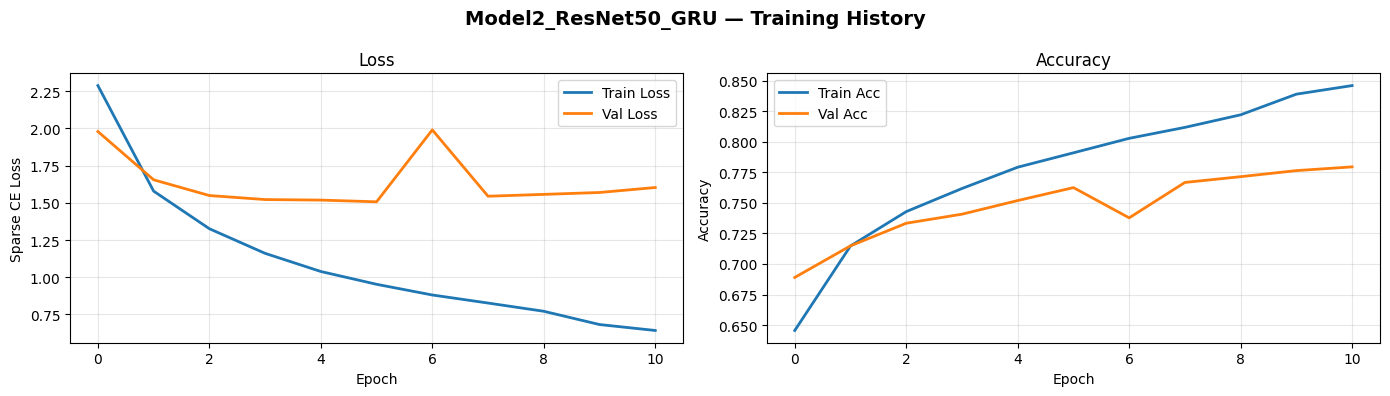

  Best val_loss   : 1.5068
  Best val_acc    : 0.7794
  Epochs run      : 11


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAIN MODEL 2: ResNet50 + GRU + Attention
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("TRAINING MODEL 2: ResNet50 + GRU + Attention")
print("=" * 60)

history2 = model2.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=EPOCHS,
    callbacks=get_callbacks("model2_resnet50_gru"),
    verbose=1
)
plot_history(history2, "Model2_ResNet50_GRU")

In [23]:
print(os.path.exists("saved_models/model2_resnet50_gru_best.keras"))

True


In [26]:
from tensorflow.keras.models import load_model

model2_loaded = load_model(
    "saved_models/model2_resnet50_gru_best.keras",
    custom_objects={
        "BahdanauAttention": BahdanauAttention
    }
)

print("Model 2 loaded successfully ✅")
model2_loaded.summary()

Model 2 loaded successfully ✅


Model: "Model2_ResNet50_GRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet50_spatial    │ (None, 49, 2048)  │ 23,587,712 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 49, 512)   │  1,049,088 │ ResNet50_spatial… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 512)   │          0 │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ dropout[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_init (Dense)    │ (None, 512)       │    262,656 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 31, 256)   │    982,272 │ caption_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 512),     │    525,825 │ dropout[0][0],    │
│ (BahdanauAttention) │ (None, 49, 1)]    │            │ gru_init[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 31)        │          0 │ caption_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 31, 512)   │          0 │ bahdanau_attenti… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims         │ (None, 31, 1)     │          0 │ not_equal[0][0]   │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like          │ (None, 31, 256)   │          0 │ word_embedding[0… │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 31, 256)   │          0 │ expand_dims[0][0… │
│ (LogicalOr)         │                   │            │ zeros_like[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like           │ (None, 31, 512)   │          0 │ repeat_vector[0]… │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 31, 768)   │          0 │ word_embedding[0… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 31, 768)   │          0 │ logical_or[0][0], │
│ (Concatenate)       │                   │            │ ones_like[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 70,211,452 (267.84 MB)

 Trainable params: 20,357,630 (77.66 MB)

 Non-trainable params: 9,138,560 (34.86 MB)

 Optimizer params: 40,715,262 (155.32 MB)

[1/8] ID=4460
  Actual   : Genuine Leather Belt For Men - Casual & Classic - Havan belts men budget egp 211
  Generated: men's leather belt belts men mid range egp 350 0
  BLEU-1=0.274  BLEU-4=0.037

[2/8] ID=2030
  Actual   : Belts - Metal - Woman - Stylish and Durable Accessories belts women mid-range eg
  Generated: men's leather belt belts men budget egp 299 0
  BLEU-1=0.114  BLEU-4=0.015

[3/8] ID=166
  Actual   : Carrot Fit High Waist Straight Leg Long Soft Jeans jeans women budget egp 225.0
  Generated: lc waikiki crew neck floral frilled mini dress dresses women mid range egp 429 0
  BLEU-1=0.133  BLEU-4=0.016

[4/8] ID=5621
  Actual   : Defacto Girl Crew Neck Oversize Fit Sweat Shirt - Ecru ecru hoodies & sweatshirt
  Generated: lc waikiki crew neck printed jersey men's t shirt t shirts men mid range egp 449
  BLEU-1=0.222  BLEU-4=0.027

[5/8] ID=727
  Actual   : Women's brown faux leather handbag, medium size - a stylish shoulder bag for eve
  Generated: men's fur lined milto

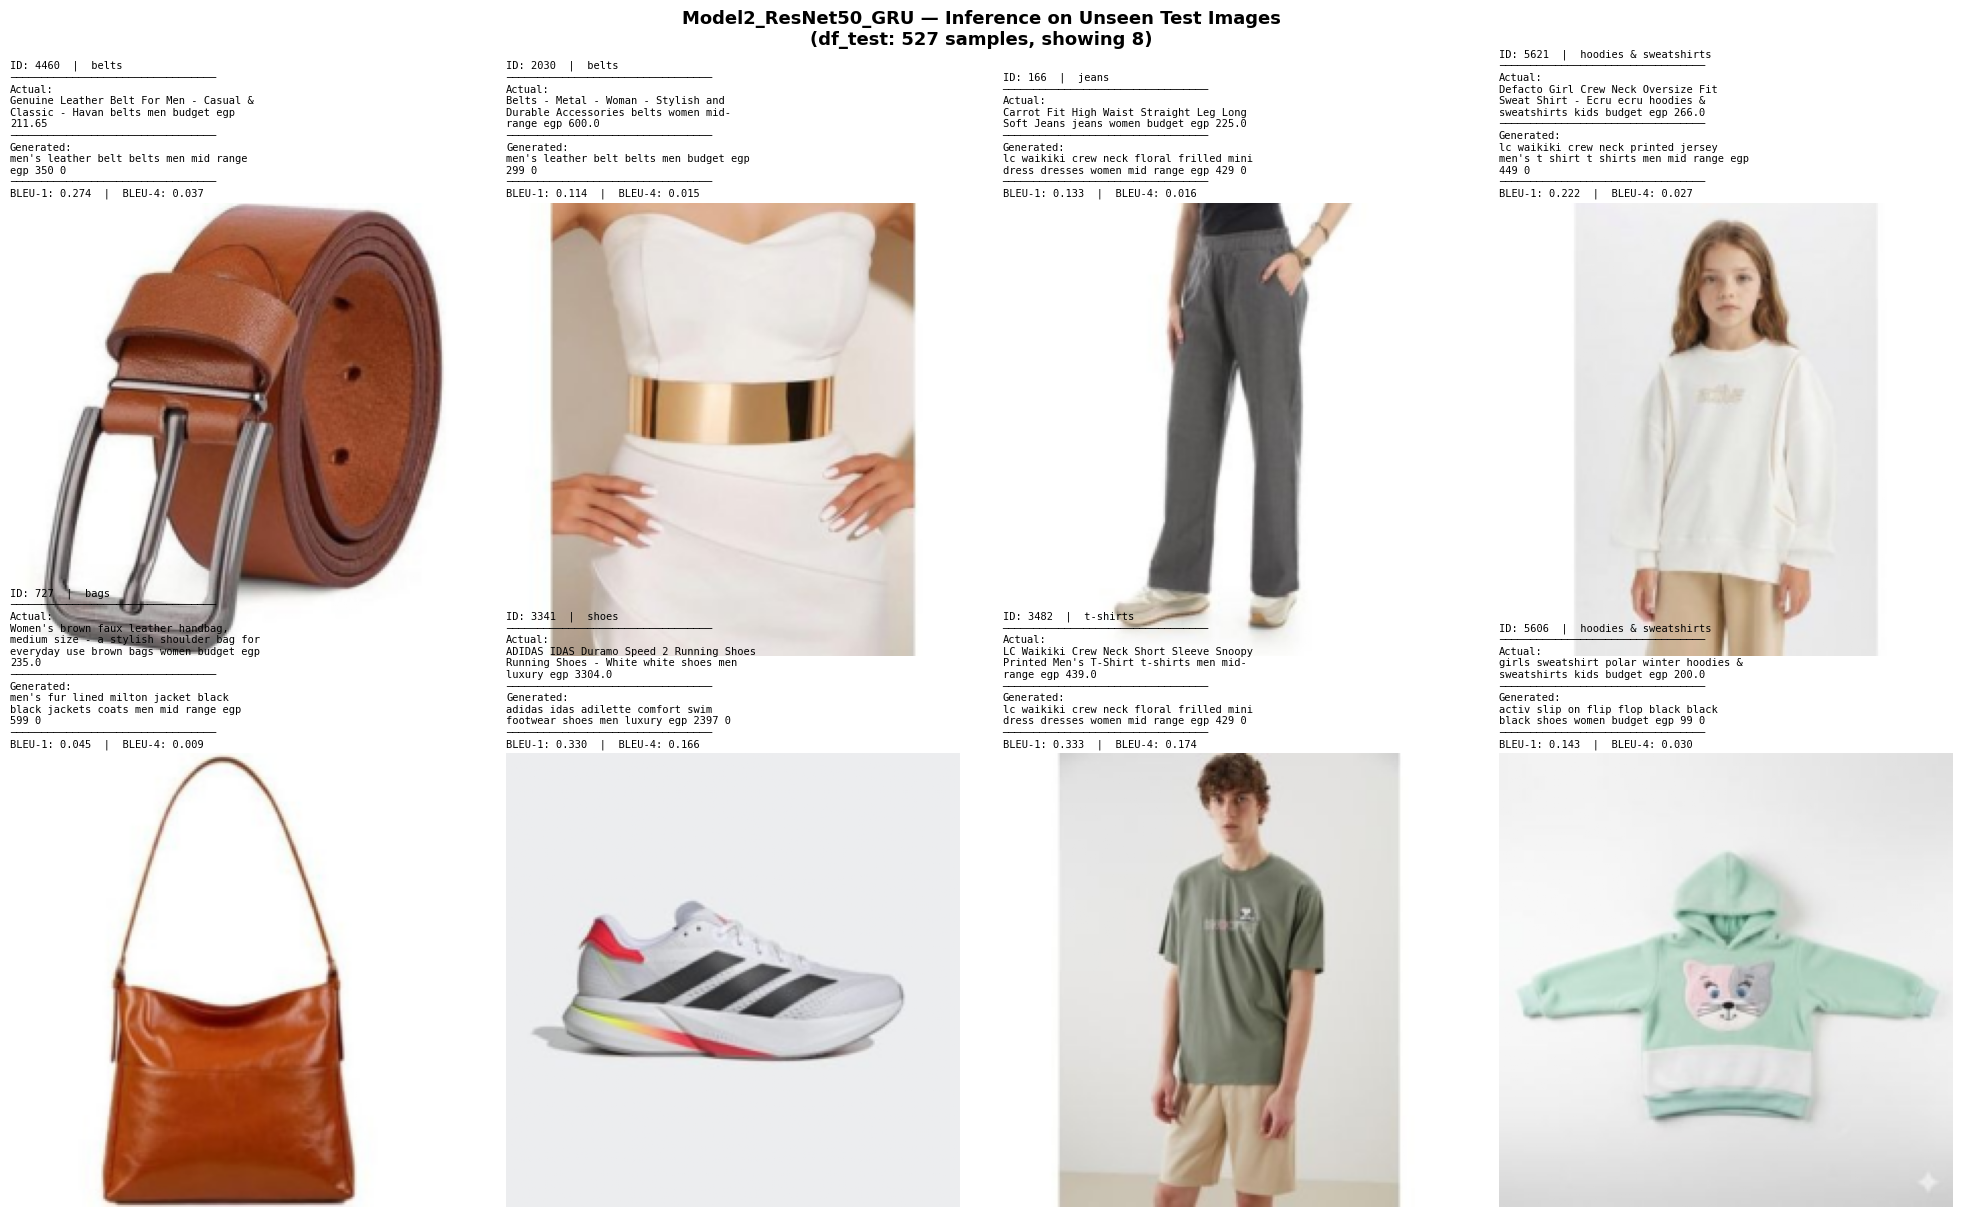

  Model2_ResNet50_GRU — Test Set Summary
  Samples evaluated : 8
  Mean BLEU-1       : 0.1993
  Mean BLEU-4       : 0.0592


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2 — INFERENCE & EVALUATION ON UNSEEN TEST DATA
# ══════════════════════════════════════════════════════════════════════════════

import textwrap
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_on_test(model, df_test, n_samples=8,
                    model_name="Model",
                    preproc_fn=None):
    """
    Randomly sample n_samples from df_test, generate captions,
    display image + actual vs generated caption + BLEU scores.
    """
    if preproc_fn is None:
        preproc_fn = resnet_preproc

    samples = df_test.sample(n_samples, random_state=SEED).reset_index(drop=True)

    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * 5, n_rows * 6))
    axes = axes.flatten()

    fig.suptitle(
        f"{model_name} — Inference on Unseen Test Images\n"
        f"(df_test: {len(df_test)} samples, showing {n_samples})",
        fontsize=13, fontweight="bold", y=1.01
    )

    all_bleu1 = []
    all_bleu4 = []

    for idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[idx]

        # ── Load image ────────────────────────────────────────────────────
        img_array      = load_image_from_disk(row["product_id"])
        is_placeholder = np.allclose(img_array, 0.5)

        # ── Preprocess for this model's CNN ───────────────────────────────
        img_pre = preproc_fn(img_array * 255.0)
        img_pre = np.expand_dims(img_pre, 0)         # (1,224,224,3)

        # ── Generate caption (greedy) ─────────────────────────────────────
        token_seq = [START_ID]
        for _ in range(MAX_SEQ_LEN - 1):
            padded  = pad_sequences(
                [token_seq], maxlen=MAX_SEQ_LEN - 1, padding="post"
            )
            preds   = model.predict([img_pre, padded], verbose=0)
            step    = min(len(token_seq) - 1, MAX_SEQ_LEN - 2)
            next_id = int(np.argmax(preds[0, step, :]))
            if next_id == END_ID:
                break
            token_seq.append(next_id)

        words = []
        for tid in token_seq[1:]:
            word = index_word.get(tid, "")
            if word in (END_TOKEN, PAD_TOKEN, ""):
                break
            words.append(word)
        generated = " ".join(words)

        # ── Actual caption ────────────────────────────────────────────────
        actual       = row["caption"]
        actual_clean = actual.replace(START_TOKEN, "").replace(
                        END_TOKEN, "").strip()

        # ── BLEU scores ───────────────────────────────────────────────────
        sf  = SmoothingFunction().method1
        ref = [w for w in actual_clean.lower().split()
            if w not in (START_TOKEN, END_TOKEN, PAD_TOKEN)]
        hyp = generated.lower().split()

        b1 = sentence_bleu([ref], hyp, weights=(1,0,0,0),
                            smoothing_function=sf)
        b4 = sentence_bleu([ref], hyp, weights=(0.25,0.25,0.25,0.25),
                            smoothing_function=sf)
        all_bleu1.append(b1)
        all_bleu4.append(b4)

        # ── Display ───────────────────────────────────────────────────────
        ax.imshow(img_array)
        ax.axis("off")

        actual_wrapped    = "\n".join(textwrap.wrap(actual_clean, width=40))
        generated_wrapped = "\n".join(textwrap.wrap(generated,    width=40))

        title = (
            f"ID: {row['product_id']}  |  "
            f"{'⚠ placeholder' if is_placeholder else row.get('category_clean','')}\n"
            f"─────────────────────────────────\n"
            f"Actual:\n{actual_wrapped}\n"
            f"─────────────────────────────────\n"
            f"Generated:\n{generated_wrapped}\n"
            f"─────────────────────────────────\n"
            f"BLEU-1: {b1:.3f}  |  BLEU-4: {b4:.3f}"
        )
        ax.set_title(title, fontsize=7.5, loc="left",
                    pad=4, family="monospace")

        print(f"[{idx+1}/{n_samples}] ID={row['product_id']}")
        print(f"  Actual   : {actual_clean[:80]}")
        print(f"  Generated: {generated[:80]}")
        print(f"  BLEU-1={b1:.3f}  BLEU-4={b4:.3f}")
        print()

    # Hide unused axes
    for ax in axes[n_samples:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(str(LOGS_DIR / f"{model_name}_test_inference.png"),
                dpi=120, bbox_inches="tight")
    plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print("=" * 55)
    print(f"  {model_name} — Test Set Summary")
    print("=" * 55)
    print(f"  Samples evaluated : {n_samples}")
    print(f"  Mean BLEU-1       : {np.mean(all_bleu1):.4f}")
    print(f"  Mean BLEU-4       : {np.mean(all_bleu4):.4f}")
    print("=" * 55)

    return {
        "mean_bleu1": np.mean(all_bleu1),
        "mean_bleu4": np.mean(all_bleu4),
        "samples":    samples,
    }


# ── RUN ───────────────────────────────────────────────────────────────────────
results_model2 = evaluate_on_test(
    model      = model2_loaded,
    df_test    = df_test,
    n_samples  = 8,
    model_name = "Model2_ResNet50_GRU",
    preproc_fn = resnet_preproc,
)